In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
#finetnuing using Roboflow data
!pip install roboflow
from roboflow import Roboflow
rf = Roboflow(api_key="PMLIf0n6W9pGHgrQErf4")

In [ ]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("PyTorch is not currently using CUDA. You might need to install a CUDA-enabled version or change your runtime type.")

CUDA available: True
CUDA device name: Tesla T4
CUDA version: 12.8


In [ ]:
import os

# Load the pre-trained YOLOv11-Medium model
# Please replace 'path/to/your/image.jpg' with the actual path to your image file.
# For example, if you upload an image named 'my_image.jpg' to the Colab environment,
# you can set img_path = 'my_image.jpg'
img_path = "/content/drive/MyDrive/CV Project/data_samples/IMG_1928.jpg"
model_type = "yolo26s.pt"
yolo_output_dir = "/content/drive/MyDrive/CV Project"

prediction(model_type, img_path, task = "Object Detection", output_project_name=yolo_output_dir)

Processing image: /content/drive/MyDrive/CV Project/data_samples/IMG_1928.jpg

image 1/1 /content/drive/MyDrive/CV Project/data_samples/IMG_1928.jpg: 640x384 3 persons, 636.3ms
Speed: 6.7ms preprocess, 636.3ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/drive/MyDrive/CV Project/predict


KeyboardInterrupt: 

In [ ]:


#download stairs data
project = rf.workspace("tom-lai-8bp7n").project("stairs-i2yia")
version = project.version(3)
dataset = version.download("yolo26", location="/content/drive/MyDrive/CV Project/Stairs-3")

In [ ]:
#download crosswalk data
project = rf.workspace("project-rdlha").project("cross-vgnt6")
version = project.version(1)
dataset = version.download("yolo26", location="/content/drive/MyDrive/CV Project/Crosswalk")


In [ ]:
#download walk/dont walk/crosswalk data


project = rf.workspace("walkassist").project("walk-assist")
version = project.version(3)
dataset = version.download("yolo26",location="/content/drive/MyDrive/CV Project/Walksigns")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/CV Project/Walksigns in yolo26:: 100%|██████████| 409/409 [00:04<00:00, 87.61it/s]


In [ ]:
#download house fence data
project = rf.workspace("housevsbench").project("fence-eq-2guat")
version = project.version(1)
dataset = version.download("yolo26",location="/content/drive/MyDrive/CV Project/Fence")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/CV Project/Fence in yolo26:: 100%|██████████| 205/205 [00:02<00:00, 75.65it/s]


In [ ]:
#crosswalk, road, sidewalk data
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="PMLIf0n6W9pGHgrQErf4")
project = rf.workspace("usrg2").project("crosswalk-lpcig")
version = project.version(5)
dataset = version.download("yolo26",location="/content/drive/MyDrive/CV Project/Cross-road-side")



loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/drive/MyDrive/CV Project/Cross-road-side in yolo26:: 100%|██████████| 751/751 [00:10<00:00, 68.74it/s]


In [ ]:
#add electric scooter data


In [ ]:
#add lawn/trees data

In [ ]:
#add poles data


In [ ]:
#add pedestrian walk/dont walk data


### Fine-tuning YOLOv26s model on `cross-road-side` dataset

This cell will initiate the training process for the YOLOv26s model. It will use the `cross-road-side` dataset, freeze the first 10 layers, and apply the specified hyperparameters for optimization.

In [ ]:
from ultralytics import YOLO

# Define the path to the data.yaml file for the cross-road-side dataset
data_yaml_path = "/content/drive/MyDrive/CV Project/Cross-road-side/data.yaml"

# Load the YOLOv26s model (already downloaded in a previous cell)
model = YOLO("yolo26s.pt")

# Start training with specified parameters
# Freeze the first 10 layers to retain pre-trained feature extraction capabilities
# Adjust learning rate, disable mosaic, mixup, and copy_paste augmentations, and use AdamW optimizer
results = model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    freeze=10,
    lr0=0.001,
    mosaic=0.5,
    mixup=0.0,
    copy_paste=0.0,
    optimizer='AdamW',
    project="/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results", # Optional: Define a project directory for results
    name="cross_road_side_yolo26s_frozen10" # Optional: Name for this specific run
)

print("Training completed!")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/CV Project/Cross-road-side/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=cross_road_side_yolo26s_frozen10-2, nbs=64, nms=False, opset=None, optimi

### Model Performance Graphs

After training, Ultralytics YOLO saves various plots in the project directory to help you visualize the model's performance. Let's list the contents of the results directory and then display some of the most important graphs.

Contents of the results directory: /content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2
- weights
- args.yaml
- labels.jpg
- train_batch0.jpg
- train_batch1.jpg
- train_batch2.jpg
- results.csv
- train_batch840.jpg
- train_batch841.jpg
- train_batch842.jpg
- BoxPR_curve.png
- val_batch0_labels.jpg
- val_batch0_pred.jpg
- BoxF1_curve.png
- BoxP_curve.png
- BoxR_curve.png
- confusion_matrix_normalized.png
- confusion_matrix.png
- results.png

--- Displaying Key Performance Plots ---


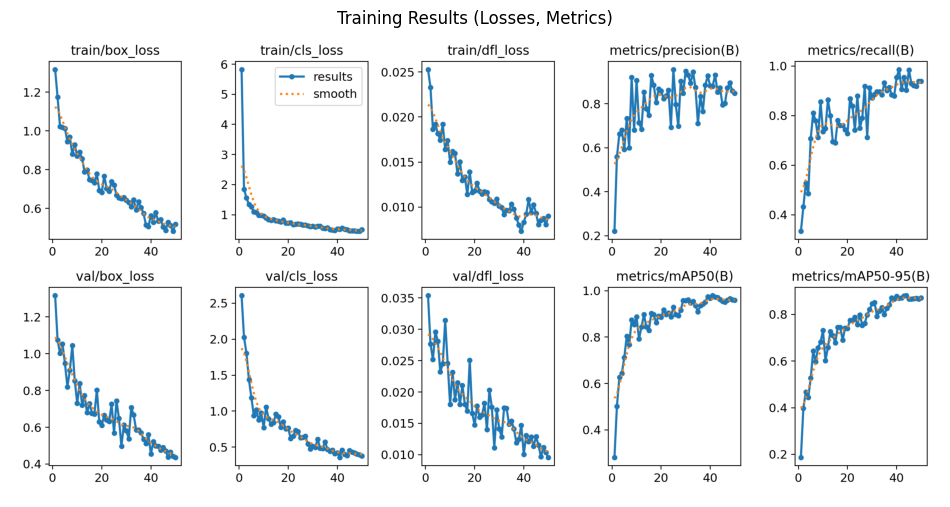

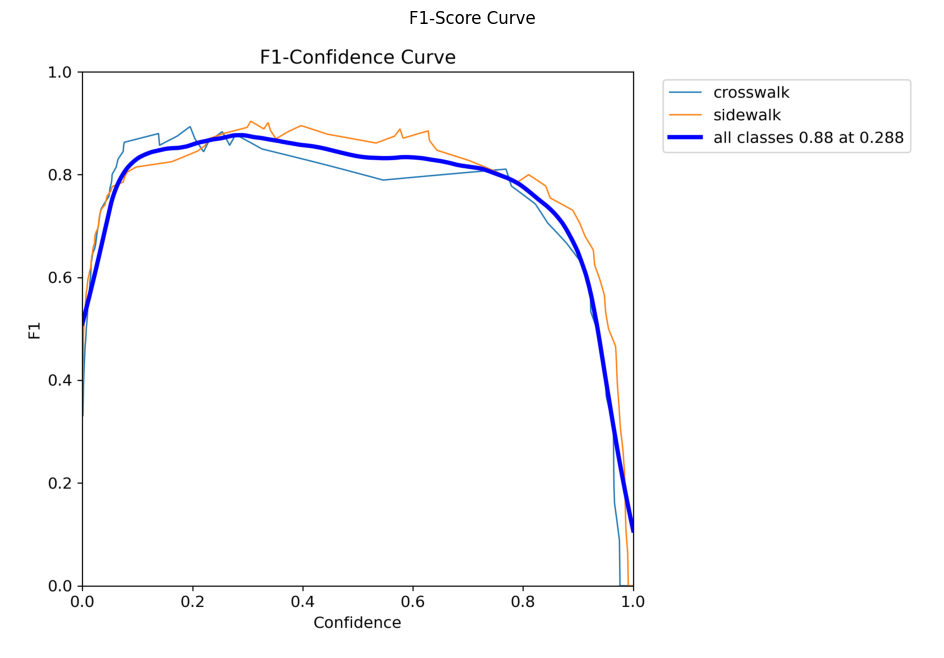

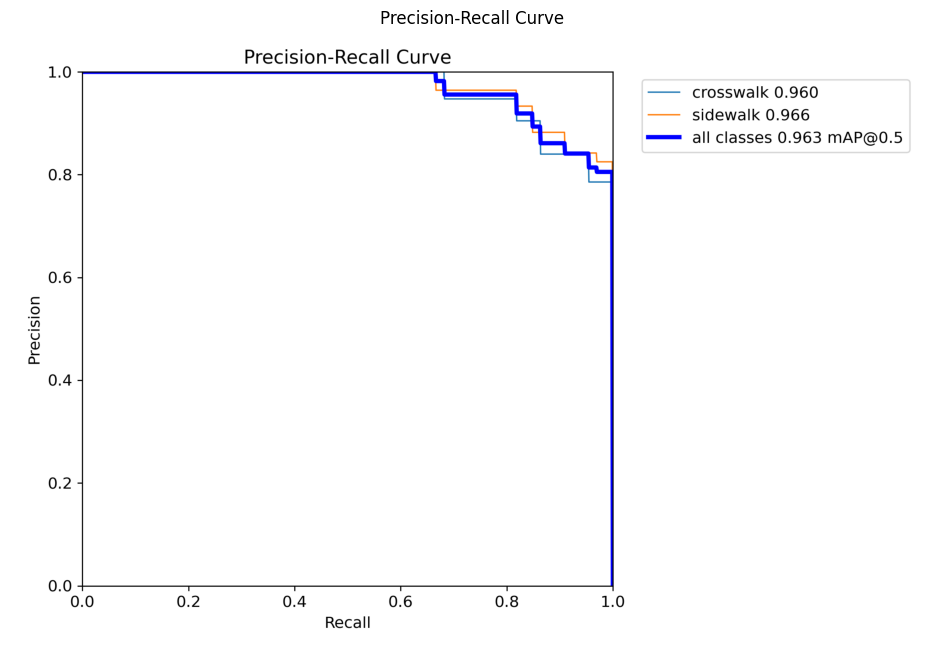

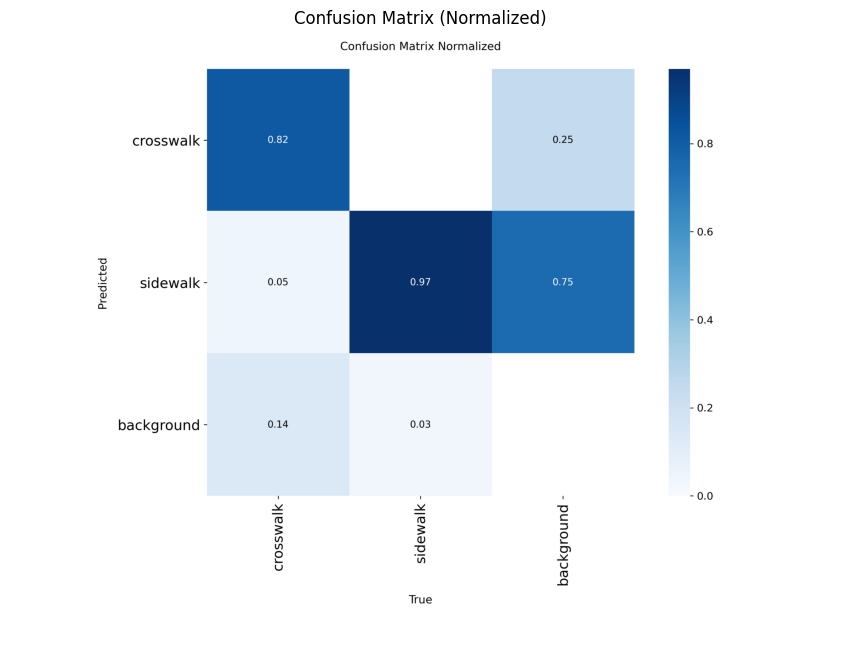

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

# Define the directory where training results were saved
# This path comes from the 'project' and 'name' parameters used in model.train()
results_dir = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2"

# List all files in the results directory
print(f"Contents of the results directory: {results_dir}")
if os.path.exists(results_dir):
    for item in os.listdir(results_dir):
        print(f"- {item}")
else:
    print(f"Error: Results directory not found at {results_dir}")

# Function to display an image
def display_image(path, title):
    if os.path.exists(path):
        img = cv2.imread(path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(12, 8))
            plt.imshow(img_rgb)
            plt.title(title)
            plt.axis('off')
            plt.show()
        else:
            print(f"Could not load image: {path}")
    else:
        print(f"Image not found: {path}")

print("\n--- Displaying Key Performance Plots ---")

# Display the overall results plot (often named 'results.png')
display_image(os.path.join(results_dir, 'results.png'), 'Training Results (Losses, Metrics)')

# Display the F1-curve (corrected filename)
display_image(os.path.join(results_dir, 'BoxF1_curve.png'), 'F1-Score Curve')

# Display the Precision-Recall curve (corrected filename)
display_image(os.path.join(results_dir, 'BoxPR_curve.png'), 'Precision-Recall Curve')

# Display the Confusion Matrix (normalized)
display_image(os.path.join(results_dir, 'confusion_matrix_normalized.png'), 'Confusion Matrix (Normalized)')

# Optionally, display others if needed
# display_image(os.path.join(results_dir, 'P_curve.png'), 'Precision Curve')
# display_image(os.path.join(results_dir, 'R_curve.png'), 'Recall Curve')
# display_image(os.path.join(results_dir, 'train_batch0.jpg'), 'Example Training Batch with Labels')


### Using the Newly Trained Model for Prediction

Now that the model is trained, let's use the `prediction` function to test it on a new image. We'll load the `best.pt` weights from your fine-tuned model and use the image corresponding to the label file you provided.

In [ ]:
def prediction(model_type, input_path, display_result = False, task : str = None, output_project_name: str = None):

    model = YOLO(model_type)

    # Determine if the input is an image or video
    file_extension = os.path.splitext(input_path)[1].lower()
    video_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.flv'] # Add more if needed
    is_video = file_extension in video_extensions

    if is_video:
        print(f"Processing video: {input_path}")
        # Use stream=True for video to prevent out-of-memory issues
        results = model(input_path, save=True, conf=0.5, project=output_project_name, stream=True)

        first_frame_plotted = False
        save_dir_for_video = None

        for r in results: # 'results' is a generator yielding Results objects for each frame
            if not first_frame_plotted and display_result:
                # Plot the first frame with detections using matplotlib
                # r.plot() returns a numpy array (image with detections)
                frame_with_detections = r.plot()
                plt.figure(figsize=(10, 8))
                # OpenCV uses BGR by default, matplotlib expects RGB
                plt.imshow(cv2.cvtColor(frame_with_detections, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.title(f"YOLO26n - {task} (First Detected Frame)")
                plt.show()
                first_frame_plotted = True

            # Get the save_dir once from the first result object
            if save_dir_for_video is None and hasattr(r, 'save_dir'):
                save_dir_for_video = r.save_dir

        if save_dir_for_video:
            print(f"Video processed and saved to: {save_dir_for_video}")
        else:
            print("Video processed. Output directory could not be determined.")

    else: # Assume it's an image
        print(f"Processing image: {input_path}")
        results = model(input_path, save = True, conf=0.5, project=output_project_name)

        for r in results:
            # Construct the path to the saved predicted image correctly
            pred_img_path = os.path.join(r.save_dir, os.path.basename(input_path))
            pred = cv2.cvtColor(cv2.imread(pred_img_path), cv2.COLOR_BGR2RGB)
            plt.imshow(pred)
            plt.axis('off')
            plt.title(f"YOLO26n - {task}")
        plt.show()

        # To print the results
        if display_result:
           print(results)

Using model: /content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt
Predicting on image: /content/drive/MyDrive/CV Project/Fence/test/images/wooden_fence_83_jpg.rf.4a38a0fd49b8a7ed074e889634ba923b.jpg
Processing image: /content/drive/MyDrive/CV Project/Fence/test/images/wooden_fence_83_jpg.rf.4a38a0fd49b8a7ed074e889634ba923b.jpg

image 1/1 /content/drive/MyDrive/CV Project/Fence/test/images/wooden_fence_83_jpg.rf.4a38a0fd49b8a7ed074e889634ba923b.jpg: 384x640 (no detections), 63.1ms
Speed: 2.0ms preprocess, 63.1ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/drive/MyDrive/CV Project/predict-2


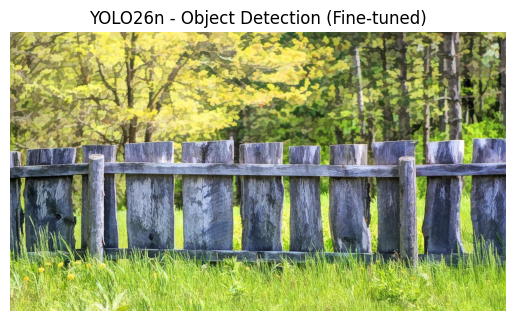

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[118, 161, 164],
        [114, 157, 160],
        [114, 157, 160],
        ...,
        [ 78, 165, 169],
        [ 77, 163, 169],
        [ 74, 162, 168]],

       [[118, 161, 164],
        [113, 156, 159],
        [110, 153, 156],
        ...,
        [ 79, 166, 170],
        [ 76, 164, 170],
        [ 74, 165, 170]],

       [[122, 163, 166],
        [115, 156, 159],
        [111, 152, 155],
        ...,
        [ 77, 168, 172],
        [ 75, 167, 172],
        [ 74, 166, 171]],

       ...,

       [[106, 202, 196],
        [ 87, 183, 176],
        [ 54, 150, 143],
        ...,
        [ 57, 191, 161],
        [ 51, 183, 153],
        [ 62, 192, 162]],

       [[106, 200, 195],
        [ 86, 181, 174],
        [ 59, 155, 148],
        ...,
        [ 65, 196, 169],
        [ 57, 184, 

In [ ]:
# Define the path to the best weights of your newly trained model
fine_tuned_model_path = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt"

# The user provided a label file path, we need to derive the corresponding image path
label_file_path = "/content/drive/MyDrive/CV Project/Fence/test/labels/wooden_fence_83_jpg.rf.4a38a0fd49b8a7ed074e889634ba923b.txt"

# Extract the base filename and construct the image path
base_filename_no_ext = os.path.splitext(os.path.basename(label_file_path))[0]
# Assuming the image is a .jpg and located in a sibling 'images' directory
image_path_for_prediction = os.path.join(
    os.path.dirname(os.path.dirname(label_file_path)),
    "images",
    base_filename_no_ext + ".jpg")

print(f"Using model: {fine_tuned_model_path}")
print(f"Predicting on image: {image_path_for_prediction}")

# Reuse the yolo_output_dir defined earlier
yolo_output_dir = "/content/drive/MyDrive/CV Project"

# Call the prediction function with the new model and image
prediction(
    model_type=fine_tuned_model_path,
    input_path=image_path_for_prediction,
    display_result=True, # Display the result in the notebook
    task="Object Detection (Fine-tuned)",
    output_project_name=yolo_output_dir
)

### Running Predictions on Cross-Road-Side Test Dataset

This section will iterate through all images in the `test/images` directory of your `Cross-road-side` dataset and perform predictions using the fine-tuned YOLOv26s model. This helps evaluate the model's performance on unseen data from its training distribution.

Loading fine-tuned model: /content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt
Searching for test images in: /content/drive/MyDrive/CV Project/Cross-road-side/test/images
Found 16 test images. Performing predictions...

--- Predicting on image 1/16: image_1756977035_604341030_jpg.rf.db505386f2b0ffd7f83d2d4286bc9d58.jpg ---
Processing image: /content/drive/MyDrive/CV Project/Cross-road-side/test/images/image_1756977035_604341030_jpg.rf.db505386f2b0ffd7f83d2d4286bc9d58.jpg

image 1/1 /content/drive/MyDrive/CV Project/Cross-road-side/test/images/image_1756977035_604341030_jpg.rf.db505386f2b0ffd7f83d2d4286bc9d58.jpg: 640x640 1 sidewalk, 17.0ms
Speed: 1.8ms preprocess, 17.0ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/CV Project/predict-3


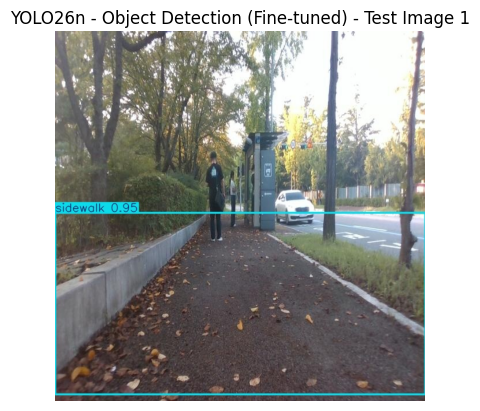

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[136, 120, 131],
        [137, 123, 134],
        [134, 126, 136],
        ...,
        [255, 255, 252],
        [254, 250, 245],
        [255, 255, 247]],

       [[135, 119, 130],
        [137, 123, 134],
        [133, 125, 135],
        ...,
        [248, 243, 240],
        [255, 255, 251],
        [255, 254, 246]],

       [[134, 118, 129],
        [135, 121, 132],
        [132, 123, 133],
        ...,
        [218, 214, 209],
        [255, 255, 248],
        [255, 255, 247]],

       ...,

       [[ 56,  65,  98],
        [ 55,  64,  97],
        [ 57,  65,  95],
        ...,
        [ 56,  58,  69],
        [ 58,  60,  71],
        [ 59,  61,  72]],

       [[ 54,  65,  97],
        [ 54,  63,  96],
        [ 55,  63,  93],
        ...,
        [ 56,  58,  69],
        [ 57,  59, 

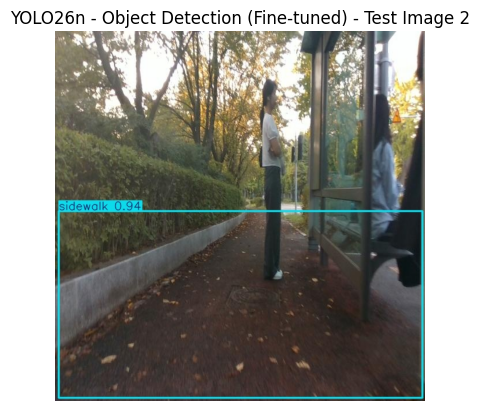

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[110, 129, 137],
        [111, 130, 138],
        [110, 129, 137],
        ...,
        [119, 123, 141],
        [131, 139, 152],
        [133, 142, 152]],

       [[110, 129, 137],
        [111, 130, 138],
        [112, 131, 139],
        ...,
        [119, 123, 141],
        [132, 138, 151],
        [132, 141, 151]],

       [[110, 128, 139],
        [112, 130, 141],
        [114, 132, 143],
        ...,
        [117, 122, 137],
        [130, 136, 147],
        [135, 142, 151]],

       ...,

       [[ 63,  53,  65],
        [ 61,  51,  63],
        [ 61,  51,  63],
        ...,
        [ 29,  40,  48],
        [ 25,  34,  47],
        [ 21,  33,  45]],

       [[ 63,  53,  66],
        [ 62,  52,  64],
        [ 62,  52,  64],
        ...,
        [ 27,  38,  46],
        [ 25,  34, 

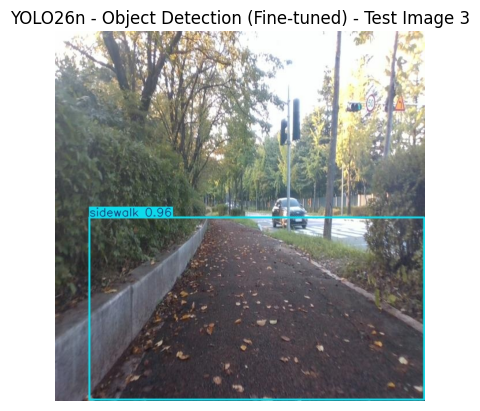

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [251, 255, 255],
        [255, 253, 255],
        [255, 250, 252]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [248, 252, 253],
        [255, 253, 255],
        [255, 253, 255]],

       [[254, 254, 254],
        [254, 254, 254],
        [254, 254, 254],
        ...,
        [246, 250, 251],
        [255, 252, 255],
        [255, 253, 255]],

       ...,

       [[ 98,  85,  93],
        [ 98,  85,  93],
        [ 97,  84,  92],
        ...,
        [ 65,  58,  65],
        [ 65,  57,  64],
        [ 65,  57,  64]],

       [[100,  87,  95],
        [101,  88,  96],
        [100,  87,  95],
        ...,
        [ 65,  57,  67],
        [ 64,  56, 

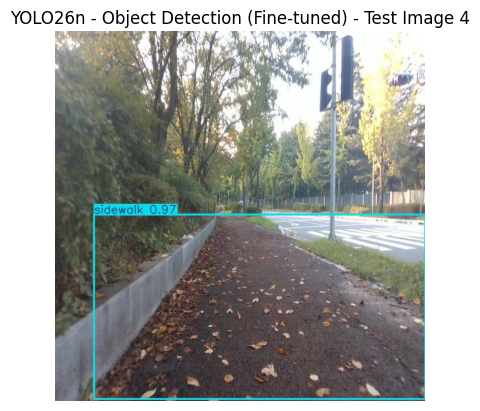

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[171, 181, 191],
        [165, 175, 185],
        [162, 172, 182],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[170, 180, 190],
        [165, 175, 185],
        [162, 172, 182],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[167, 180, 188],
        [163, 176, 184],
        [159, 171, 181],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       ...,

       [[113, 109, 104],
        [113, 109, 104],
        [112, 107, 104],
        ...,
        [ 56,  55,  71],
        [ 58,  56,  75],
        [ 63,  63,  81]],

       [[114, 110, 105],
        [115, 111, 106],
        [115, 110, 107],
        ...,
        [ 63,  60,  75],
        [ 62,  59, 

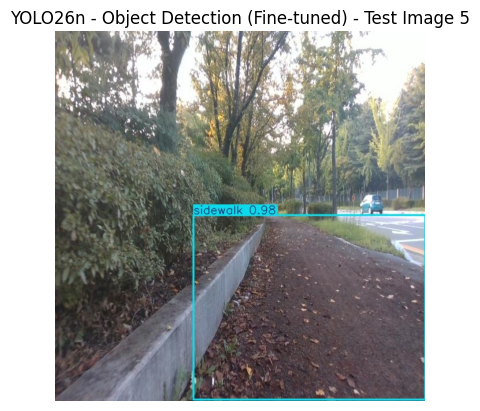

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[ 94, 125, 128],
        [ 94, 125, 128],
        [ 97, 124, 128],
        ...,
        [254, 255, 253],
        [254, 255, 253],
        [254, 255, 253]],

       [[ 95, 126, 129],
        [ 96, 125, 129],
        [ 97, 124, 128],
        ...,
        [254, 255, 253],
        [254, 255, 253],
        [254, 255, 253]],

       [[ 98, 127, 131],
        [ 97, 126, 130],
        [ 97, 124, 128],
        ...,
        [254, 255, 253],
        [254, 255, 253],
        [254, 255, 253]],

       ...,

       [[ 96,  85, 105],
        [ 98,  87, 107],
        [ 99,  89, 106],
        ...,
        [ 84,  77,  90],
        [ 83,  76,  89],
        [ 82,  75,  88]],

       [[ 99,  88, 108],
        [ 98,  87, 107],
        [ 97,  87, 104],
        ...,
        [ 85,  78,  91],
        [ 85,  78, 

In [ ]:
import os
import yaml
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# Re-using variables defined in previous cells
fine_tuned_model_path = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt"
yolo_output_dir = "/content/drive/MyDrive/CV Project"

data_yaml_path = "/content/drive/MyDrive/CV Project/Cross-road-side/data.yaml"

# Read the data.yaml file to get the test image directory
with open(data_yaml_path, 'r') as file:
    data = yaml.safe_load(file)

dataset_base_dir = os.path.dirname(data_yaml_path)

# Correct path handling for Roboflow datasets if they use '../'
if 'test' in data and data['test'].startswith('../'):
    data['test'] = data['test'].replace('../', '', 1)

test_images_dir = os.path.join(dataset_base_dir, data['test'])

print(f"Loading fine-tuned model: {fine_tuned_model_path}")
print(f"Searching for test images in: {test_images_dir}")

# List all image files in the test directory
image_files = []
if os.path.isdir(test_images_dir):
    for filename in os.listdir(test_images_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
            image_files.append(os.path.join(test_images_dir, filename))
    image_files.sort() # Sort for consistent order
else:
    print(f"Error: Test images directory not found at {test_images_dir}")

if not image_files:
    print("No image files found in the test directory.")
else:
    print(f"Found {len(image_files)} test images. Performing predictions...")

    # Process a few sample images or all if desired
    # For demonstration, let's process up to the first 5 images.
    # You can change `[:5]` to `[:]` to process all images.
    for i, img_path in enumerate(image_files[:5]): # Limiting to first 5 for brevity
        print(f"\n--- Predicting on image {i+1}/{len(image_files)}: {os.path.basename(img_path)} ---")
        prediction(
            model_type=fine_tuned_model_path,
            input_path=img_path,
            display_result=True,
            task=f"Object Detection (Fine-tuned) - Test Image {i+1}",
            output_project_name=yolo_output_dir
        )
    print("\n--- All selected test predictions completed --- ")

### Evaluate Model Performance on the Entire Test Dataset

Now, let's run a full evaluation of the fine-tuned model on the entire test dataset to get a comprehensive set of performance metrics including mAP (Mean Average Precision), precision, and recall.

In [ ]:
from ultralytics import YOLO

# Define the path to the fine-tuned model weights
fine_tuned_model_path = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt"

# Define the path to the data.yaml file, which specifies the test set location
data_yaml_path = "/content/drive/MyDrive/CV Project/Cross-road-side/data.yaml"

# Load the fine-tuned model
model = YOLO(fine_tuned_model_path)

print(f"Evaluating model: {fine_tuned_model_path} on test dataset defined in {data_yaml_path}")

# Perform validation on the test split of the dataset
# The 'split="test"' argument ensures evaluation is done on the test set defined in data.yaml
metrics = model.val(data=data_yaml_path, split="test")

# Extract and print key performance metrics
print("\n--- Test Set Evaluation Results ---")
# Access overall metrics from results_dict for robustness
print(f"Precision (P): {metrics.results_dict['metrics/precision(B)']:.3f}")
print(f"Recall (R): {metrics.results_dict['metrics/recall(B)']:.3f}")
print(f"mAP50: {metrics.results_dict['metrics/mAP50(B)']:.3f}")
print(f"mAP50-95: {metrics.results_dict['metrics/mAP50-95(B)']:.3f}")

# You can also access class-specific metrics if needed
print("\nClass-specific mAP50:")
# metrics.box.ap_per_class is a numpy array (num_classes, 4) with [P, R, mAP50, mAP50-95] for each class
if hasattr(metrics.box, 'ap_per_class') and metrics.box.ap_per_class is not None:
    for i, name in enumerate(model.names):
        if i < metrics.box.ap_per_class.shape[0] and metrics.box.ap_per_class.shape[1] > 2:
            # Use float() to ensure conversion from numpy.float32 to Python float
            print(f"  {name}: {float(metrics.box.ap_per_class[i, 2]):.3f}") # Index 2 is mAP50
        else:
            print(f"  {name}: N/A (metrics not available)")


Evaluating model: /content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt on test dataset defined in /content/drive/MyDrive/CV Project/Cross-road-side/data.yaml
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26s summary (fused): 122 layers, 9,465,954 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 35.1±10.8 MB/s, size: 74.4 KB)
val: Scanning /content/drive/MyDrive/CV Project/Cross-road-side/test/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16 4.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s
                   all         16         32       0.84      0.855      0.916      0.806
             crosswalk         11         13      0.824      0.769      0.898      0.762
              sidewalk         16         19      0.856      0.941      0.9

### Run Predictions on Sample Images from `CV Project/data_samples`

Let's apply the fine-tuned model to some sample images to see its real-world performance.

Found 2 sample images. Performing predictions...

--- Predicting on sample image 1/2: First-Day-Photos-1-web.jpg ---
Processing image: /content/drive/MyDrive/CV Project/data_samples/First-Day-Photos-1-web.jpg

image 1/1 /content/drive/MyDrive/CV Project/data_samples/First-Day-Photos-1-web.jpg: 448x640 1 sidewalk, 95.9ms
Speed: 3.9ms preprocess, 95.9ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/drive/MyDrive/CV Project/predict-10


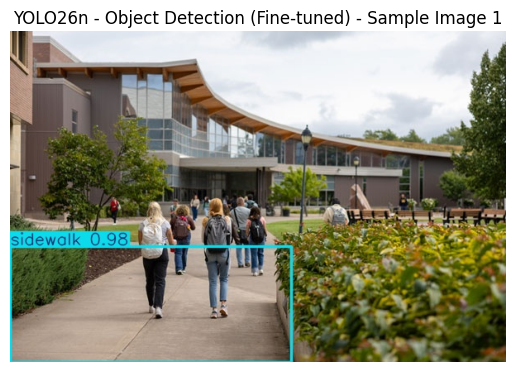

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[114, 139, 171],
        [146, 182, 206],
        [ 79, 107, 124],
        ...,
        [236, 230, 225],
        [234, 228, 223],
        [233, 227, 222]],

       [[115, 140, 172],
        [146, 182, 206],
        [ 77, 107, 124],
        ...,
        [235, 229, 224],
        [234, 228, 223],
        [233, 227, 222]],

       [[117, 142, 174],
        [148, 184, 208],
        [ 79, 109, 126],
        ...,
        [235, 229, 224],
        [234, 228, 223],
        [233, 227, 222]],

       ...,

       [[117, 131, 150],
        [117, 131, 150],
        [117, 131, 150],
        ...,
        [ 29,  71,  90],
        [ 33,  74,  96],
        [ 37,  78, 101]],

       [[118, 132, 151],
        [119, 133, 152],
        [119, 133, 152],
        ...,
        [ 29,  68,  83],
        [ 34,  72, 

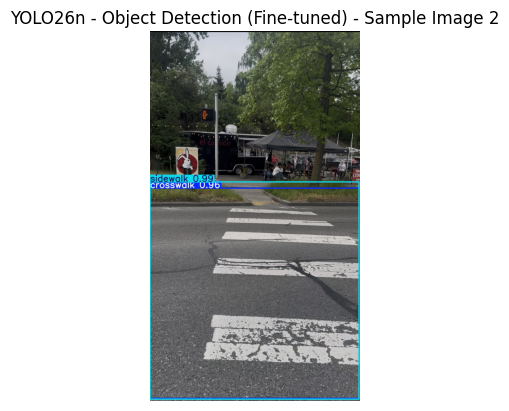

[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'crosswalk', 1: 'sidewalk'}
obb: None
orig_img: array([[[  3,   2,   4],
        [  0,   0,   1],
        [  0,   0,   1],
        ...,
        [  0,   0,   1],
        [  0,   0,   1],
        [  0,   0,   0]],

       [[  3,   2,   4],
        [  0,   0,   1],
        [  0,   0,   1],
        ...,
        [  0,   0,   1],
        [  0,   0,   1],
        [  3,   1,   1]],

       [[  1,   1,   1],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  3,   1,   1],
        [  2,   0,   0],
        [  4,   0,   0]],

       ...,

       [[101,  99,  99],
        [104, 102, 102],
        [107, 105, 105],
        ...,
        [ 82,  82,  82],
        [ 84,  84,  84],
        [ 86,  86,  86]],

       [[115, 113, 113],
        [112, 110, 110],
        [108, 106, 106],
        ...,
        [ 79,  79,  79],
        [ 80,  80, 

In [ ]:
import os
from ultralytics import YOLO

# Define the path to the fine-tuned model weights
fine_tuned_model_path = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt"

# Define the directory containing sample images
sample_data_dir = "/content/drive/MyDrive/CV Project/data_samples"

# Reuse the yolo_output_dir defined earlier
yolo_output_dir = "/content/drive/MyDrive/CV Project"

# List all image files in the sample data directory
sample_image_files = []
if os.path.isdir(sample_data_dir):
    for filename in os.listdir(sample_data_dir):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
            sample_image_files.append(os.path.join(sample_data_dir, filename))
    sample_image_files.sort() # Sort for consistent order
else:
    print(f"Error: Sample data directory not found at {sample_data_dir}")

if not sample_image_files:
    print("No image files found in the sample data directory.")
else:
    print(f"Found {len(sample_image_files)} sample images. Performing predictions...")

    for i, img_path in enumerate(sample_image_files):
        print(f"\n--- Predicting on sample image {i+1}/{len(sample_image_files)}: {os.path.basename(img_path)} ---")
        prediction(
            model_type=fine_tuned_model_path,
            input_path=img_path,
            display_result=True,
            task=f"Object Detection (Fine-tuned) - Sample Image {i+1}",
            output_project_name=yolo_output_dir
        )
    print("\n--- All sample predictions completed ---")


### Running Object Detection on Sample Video Files using `prediction` function

Let's apply the fine-tuned model to the sample video files in your `data_samples` directory using the `prediction` function. This will perform object detection on each video and save the results.

In [ ]:
import os
from ultralytics import YOLO # Ensure YOLO is imported, though it might be already

# Define the path to the fine-tuned model weights
fine_tuned_model_path = "/content/drive/MyDrive/CV Project/YOLO_FineTuning_Results/cross_road_side_yolo26s_frozen10-2/weights/best.pt"

# Define the directory containing sample videos
sample_data_dir = "/content/drive/MyDrive/CV Project/data_samples"

# Reuse the yolo_output_dir defined earlier
yolo_output_dir = "/content/drive/MyDrive/CV Project"

# List all video files in the sample data directory
sample_video_files = []
video_extensions = ('.mp4', '.avi', '.mov', '.mkv', '.flv')

if os.path.isdir(sample_data_dir):
    for filename in os.listdir(sample_data_dir):
        if filename.lower().endswith(video_extensions):
            sample_video_files.append(os.path.join(sample_data_dir, filename))
    sample_video_files.sort() # Sort for consistent order
else:
    print(f"Error: Sample data directory not found at {sample_data_dir}")

if not sample_video_files:
    print("No video files found in the sample data directory.")
else:
    print(f"Found {len(sample_video_files)} sample video files. Performing predictions...")

    for i, video_path in enumerate(sample_video_files):
        print(f"\n--- Predicting on sample video {i+1}/{len(sample_video_files)}: {os.path.basename(video_path)} ---")
        prediction(
            model_type=fine_tuned_model_path,
            input_path=video_path,
            display_result=False, # Set to True if you want to see frames, but can be verbose for videos
            task=f"Object Detection (Fine-tuned) - Sample Video {i+1}",
            output_project_name=yolo_output_dir
        )
    print("\n--- All selected sample video predictions completed ---")


Found 3 sample video files. Performing predictions...

--- Predicting on sample video 1/3: crosswalk, sidewalk,lawn.MOV ---
Processing video: /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV

video 1/1 (frame 1/2103) /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV: 640x384 1 crosswalk, 1 sidewalk, 12.5ms
video 1/1 (frame 2/2103) /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV: 640x384 2 crosswalks, 1 sidewalk, 11.8ms
video 1/1 (frame 3/2103) /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV: 640x384 1 crosswalk, 1 sidewalk, 11.8ms
video 1/1 (frame 4/2103) /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV: 640x384 1 crosswalk, 1 sidewalk, 11.8ms
video 1/1 (frame 5/2103) /content/drive/MyDrive/CV Project/data_samples/crosswalk, sidewalk,lawn.MOV: 640x384 1 crosswalk, 1 sidewalk, 11.8ms
video 1/1 (frame 6/2103) /content/drive/MyDrive/CV Project/data_sample

### Counting Train, Test, and Validation Data

This code will read the `data.yaml` file to find the paths to the train, test, and validation image directories, and then count the number of images in each of them.

In [ ]:
import yaml
import os

# Path to the data.yaml file, already defined in a previous cell
data_yaml_path = "/content/drive/MyDrive/CV Project/Cross-road-side/data.yaml"

# Read the data.yaml file
with open(data_yaml_path, 'r') as file:
    data = yaml.safe_load(file)

# Get the base directory of the dataset (where data.yaml is located)
dataset_base_dir = os.path.dirname(data_yaml_path)

# --- Start of fix for Roboflow relative paths ---
# Roboflow's data.yaml sometimes uses '../' which causes issues with `os.path.join`
# when the data is extracted directly into the target directory.
# We correct these paths to be relative to the dataset_base_dir directly.
for key in ['train', 'val', 'test']:
    if key in data and data[key].startswith('../'):
        data[key] = data[key].replace('../', '', 1)
# --- End of fix ---


# Function to count images in a given directory
def count_images_in_dir(directory_path):
    if not os.path.isdir(directory_path):
        return 0
    count = 0
    # List common image file extensions
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')
    for root, _, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

# Initialize counts
train_count = 0
val_count = 0
test_count = 0

# Get paths to train, val, test directories from data.yaml
if 'train' in data:
    train_dir = os.path.join(dataset_base_dir, data['train'])
    train_count = count_images_in_dir(train_dir)
    print(f"Train images found in: {train_dir}")
else:
    print("Train directory not specified in data.yaml")

if 'val' in data:
    val_dir = os.path.join(dataset_base_dir, data['val'])
    val_count = count_images_in_dir(val_dir)
    print(f"Validation images found in: {val_dir}")
else:
    print("Validation directory not specified in data.yaml")

if 'test' in data:
    test_dir = os.path.join(dataset_base_dir, data['test'])
    test_count = count_images_in_dir(test_dir)
    print(f"Test images found in: {test_dir}")
else:
    print("Test directory not specified in data.yaml")


print("\n--- Dataset Split Counts ---")
print(f"Train data: {train_count} images")
print(f"Validation data: {val_count} images")
print(f"Test data: {test_count} images")
print("--------------------------")

Train images found in: /content/drive/MyDrive/CV Project/Cross-road-side/train/images
Validation images found in: /content/drive/MyDrive/CV Project/Cross-road-side/valid/images
Test images found in: /content/drive/MyDrive/CV Project/Cross-road-side/test/images

--- Dataset Split Counts ---
Train data: 327 images
Validation data: 30 images
Test data: 16 images
--------------------------


### Merging 'Stairs' and 'Cross-road-side' Datasets

This section will combine the 'Stairs' and 'Cross-road-side' datasets. It will consolidate their respective train, validation, and test images and labels into a new unified dataset. Crucially, it will re-index the class IDs in the label files to create a continuous sequence for the combined set of classes and generate a new `data.yaml` file.

First, I will define the paths to both datasets and the new merged dataset directory. Then, I'll read the `data.yaml` files from each source dataset to understand their class names and create a mapping for the new class IDs.

In [ ]:
import os
import shutil
import yaml

# --- Configuration ---

# Paths to the original datasets (relative to your Google Drive 'CV Project' folder)
cross_road_side_base = "/content/drive/MyDrive/CV Project/Cross-road-side"
stairs_base = "/content/drive/MyDrive/CV Project/Stairs-3"

# Path for the new merged dataset
merged_dataset_base = "/content/drive/MyDrive/CV Project/Merged_Stairs_CrossRoadSide"

# Define the splits to process
SPLITS = ['train', 'valid', 'test']

# --- Function to load data.yaml ---
def load_data_yaml(dataset_path):
    data_yaml_path = os.path.join(dataset_path, 'data.yaml')
    if not os.path.exists(data_yaml_path):
        raise FileNotFoundError(f"data.yaml not found at {data_yaml_path}")
    with open(data_yaml_path, 'r') as f:
        data = yaml.safe_load(f)
    return data

# --- Load class names from both datasets ---
print("Loading class information from original datasets...")
cross_road_side_data = load_data_yaml(cross_road_side_base)
stairs_data = load_data_yaml(stairs_base)

# Get class names from each dataset
cross_road_side_names = cross_road_side_data['names']
stairs_names = stairs_data['names']

print(f"Cross-road-side classes: {cross_road_side_names}")
print(f"Stairs classes: {stairs_names}")

# --- Create a combined list of unique class names ---
combined_class_names = []
combined_class_names.extend(cross_road_side_names)
# Add stairs classes only if they are not already in the list
for name in stairs_names:
    if name not in combined_class_names:
        combined_class_names.append(name)

print(f"Combined unique class names: {combined_class_names}")

# --- Create mapping from old class IDs to new class IDs ---
old_to_new_class_mapping = {}

# Mapping for Cross-road-side
old_to_new_class_mapping['cross_road_side'] = {
    old_id: combined_class_names.index(name)
    for old_id, name in enumerate(cross_road_side_names)
}

# Mapping for Stairs
old_to_new_class_mapping['stairs'] = {
    old_id: combined_class_names.index(name)
    for old_id, name in enumerate(stairs_names)
}

print("Old to new class ID mappings:")
for dataset, mapping in old_to_new_class_mapping.items():
    print(f"  {dataset}: {mapping}")

# --- Create new merged dataset directory structure ---
os.makedirs(os.path.join(merged_dataset_base, 'images'), exist_ok=True)
os.makedirs(os.path.join(merged_dataset_base, 'labels'), exist_ok=True)
for split in SPLITS:
    os.makedirs(os.path.join(merged_dataset_base, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(merged_dataset_base, 'labels', split), exist_ok=True)

print(f"Created directory structure for merged dataset at {merged_dataset_base}")


Loading class information from original datasets...
Cross-road-side classes: ['crosswalk', 'sidewalk']
Stairs classes: ['stairs']
Combined unique class names: ['crosswalk', 'sidewalk', 'stairs']
Old to new class ID mappings:
  cross_road_side: {0: 0, 1: 1}
  stairs: {0: 2}
Created directory structure for merged dataset at /content/drive/MyDrive/CV Project/Merged_Stairs_CrossRoadSide


Now, I will process each image and its corresponding label file from both original datasets. For each label file, I will re-map the class IDs according to the new combined class list and save the updated labels in the new merged dataset directory. The images will also be copied to their respective locations.

In [ ]:
import glob

# --- Function to process a single split (train/valid/test) ---
def process_split(source_base_dir, dataset_name, split, new_mapping, destination_base_dir):
    source_images_dir = os.path.join(source_base_dir, split, 'images')
    source_labels_dir = os.path.join(source_base_dir, split, 'labels')

    destination_images_dir = os.path.join(destination_base_dir, 'images', split)
    destination_labels_dir = os.path.join(destination_base_dir, 'labels', split)

    # Use glob to handle various image extensions and ensure labels exist
    image_files = glob.glob(os.path.join(source_images_dir, "*"))

    print(f"Processing {split} split for {dataset_name} ({len(image_files)} images found)...")

    for img_path in image_files:
        img_filename = os.path.basename(img_path)
        base_filename, _ = os.path.splitext(img_filename)
        label_filename = base_filename + '.txt'
        label_path = os.path.join(source_labels_dir, label_filename)

        if not os.path.exists(label_path):
            print(f"Warning: No label file found for {img_filename} at {label_path}. Skipping.")
            continue

        # Copy image
        shutil.copy(img_path, os.path.join(destination_images_dir, img_filename))

        # Process and copy label file
        with open(label_path, 'r') as f_in:
            lines = f_in.readlines()

        new_label_lines = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                old_class_id = int(parts[0])
                # Get new class ID using the pre-defined mapping
                new_class_id = new_mapping[old_class_id]
                new_label_lines.append(f"{new_class_id} {' '.join(parts[1:])}\n")
            else:
                print(f"Warning: Malformed label line in {label_filename}: {line.strip()}")
                new_label_lines.append(line) # Keep original line if malformed

        with open(os.path.join(destination_labels_dir, label_filename), 'w') as f_out:
            f_out.writelines(new_label_lines)

# --- Process each split for both datasets ---
for split in SPLITS:
    process_split(
        source_base_dir=cross_road_side_base,
        dataset_name='cross_road_side',
        split=split,
        new_mapping=old_to_new_class_mapping['cross_road_side'],
        destination_base_dir=merged_dataset_base
    )
    process_split(
        source_base_dir=stairs_base,
        dataset_name='stairs',
        split=split,
        new_mapping=old_to_new_class_mapping['stairs'],
        destination_base_dir=merged_dataset_base
    )

print("\nAll images and label files processed and copied.")


Processing train split for cross_road_side (327 images found)...
Processing train split for stairs (1384 images found)...
Processing valid split for cross_road_side (30 images found)...
Processing valid split for stairs (183 images found)...
Processing test split for cross_road_side (16 images found)...
Processing test split for stairs (0 images found)...

All images and label files processed and copied.


Finally, I will generate the new `data.yaml` file for the merged dataset, which will include the paths to the new image and label directories and the combined list of class names.

In [ ]:
# --- Generate new data.yaml for the merged dataset ---
merged_data_yaml_content = {
    'path': merged_dataset_base,
    'train': os.path.join('images', 'train'),
    'val': os.path.join('images', 'valid'),
    'test': os.path.join('images', 'test'),
    'names': {i: name for i, name in enumerate(combined_class_names)},
    'nc': len(combined_class_names)
}

merged_data_yaml_path = os.path.join(merged_dataset_base, 'data.yaml')

with open(merged_data_yaml_path, 'w') as f:
    yaml.dump(merged_data_yaml_content, f, default_flow_style=False)

print(f"\nNew data.yaml generated at: {merged_data_yaml_path}")
print("\n--- Merging process completed successfully! --- ")



New data.yaml generated at: /content/drive/MyDrive/CV Project/Merged_Stairs_CrossRoadSide/data.yaml

--- Merging process completed successfully! --- 


In [ ]:
img_path = img_path = "/content/drive/MyDrive/CV Project/data_samples/First-Day-Photos-1-web.jpg"
prediction(model_type, img_path, task = "Object Detection", output_project_name=yolo_output_dir)

In [ ]:
# Set the input_path to a video file
video_path = "/content/drive/MyDrive/CV Project/data_samples/IMG_1903.MOV"

# Call the prediction function with the video file
prediction(model_type, video_path, task = "Object Detection", output_project_name=yolo_output_dir)

In [ ]:
# Set the input_path to a video file
video_path = "/content/drive/MyDrive/CV Project/data_samples/IMG_1903.MOV"

# Call the prediction function with the video file
prediction(model_type, video_path, task = "Object Detection", output_project_name=yolo_output_dir)

In [ ]:
model = YOLO(model_type)
model.names

In [ ]:
# Set the input_path to a video file
video_path = "/content/drive/MyDrive/CV Project/data_samples/Narrow street.MOV"

# Call the prediction function with the video file
prediction(model_type, video_path, task = "Object Detection", output_project_name=yolo_output_dir)

## MiDaS Depth Estimation

In [ ]:
pip install -q tqdm

In [ ]:
from tqdm.notebook import tqdm

In [ ]:
import cv2
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from typing import List
from tqdm.notebook import tqdm # Import tqdm for progress bar


class MiDaS:
    """Performs monocular depth estimation using Intel Labs MiDaS models.

    This class provides utilities to load a pre-trained MiDaS model,
    apply image transforms, generate depth maps, and normalize the results
    for visualization. It also supports real-time depth inference from video streams.

    Attributes:
        midas (torch.nn.Module): The MiDaS model instance.
        transform (callable): The preprocessing transform for input images.
        model_type (str): The type of MiDaS model to load.
        device (torch.device): The computation device (CPU or CUDA).
    """

    def __init__(self, model_type: str):
        """Initializes the MiDaS depth estimation class.

        Args:
            model_type (str): The model variant to use.
                Supported values:
                - "DPT_Large": Highest accuracy, slowest speed.
                - "DPT_Hybrid": Balanced accuracy and speed.
                - "MiDaS_small": Fastest, lowest accuracy.
        """
        self.midas = None
        self.transform = None
        self.model_type = model_type
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.load_model()

    def load_model(self) -> None:
        """Loads the MiDaS model from the PyTorch Hub."""
        self.midas = torch.hub.load("intel-isl/MiDaS", self.model_type)
        self.midas.to(self.device).eval()

    def transforms(self):
        """Retrieves the appropriate image preprocessing transform."""
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        if self.model_type in ["DPT_Large", "DPT_Hybrid"]:
            self.transform = midas_transforms.dpt_transform
        else:
            self.transform = midas_transforms.small_transform
        return self.transform

    def depth_map(self, batch: torch.Tensor, img: np.ndarray) -> np.ndarray:
        """Generates a depth map for a given input image batch."""
        with torch.no_grad():
            prediction = self.midas(batch)
            prediction = torch.nn.functional.interpolate(
                prediction.unsqueeze(1),
                size=img.shape[:2],
                mode="bicubic",
                align_corners=False,
            ).squeeze()
        return prediction.cpu().numpy()

    @staticmethod
    def normalize_depth(depth_map: np.ndarray) -> np.ndarray:
        """Normalizes and colorizes a depth map for visualization."""
        depth_min, depth_max = depth_map.min(), depth_map.max()
        normalized = (depth_map - depth_min) / (depth_max - depth_min)
        normalized = (normalized * 255).astype(np.uint8)
        return cv2.applyColorMap(normalized, cv2.COLORMAP_INFERNO)

    @staticmethod
    def stack_frames(frame1: np.ndarray, frame2: np.ndarray, width: int = 1280, height: int = 640) -> np.ndarray:
        """Safely stacks two frames horizontally with resizing to a fixed display resolution."""
        h, w = frame1.shape[:2]
        frame2 = cv2.resize(frame2, (w, h))
        combined = np.hstack((frame1, frame2))
        combined = cv2.resize(combined, (width, height))
        return combined

    def infer_video(self, source: str = 0, output_path: str = None, display: bool = True, max_frames: int = None) -> List[np.ndarray]:
        """Performs real-time depth estimation on a video stream and returns a list of normalized depth maps.

        Args:
            source (str): Path to the video file or 0 for webcam.
            output_path (str, optional): Path to save the output video. Defaults to None.
            display (bool, optional): Whether to display the video in real-time. Defaults to True.
            max_frames (int, optional): Maximum number of frames to process. If None, processes all frames.
        """
        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video source: {source}")

        width = 1280
        height = 640
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if max_frames is None else min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), max_frames)

        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        transform = self.transforms()

        print("🚀 Starting video depth inference...")

        all_normalized_depth_maps: List[np.ndarray] = []

        for frame_idx in tqdm(range(total_frames), desc="Processing video frames"):
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            input_batch = transform(rgb).to(self.device)

            depth = self.depth_map(input_batch, rgb)
            colored_depth = self.normalize_depth(depth)
            all_normalized_depth_maps.append(colored_depth)

            if display or writer:
                combined = self.stack_frames(frame, colored_depth, width, height)

            if display:
                # In Colab, cv2.imshow does not work directly. For demonstration,
                # we rely on showing a single frame after processing or saving to video.
                pass

            if writer:
                writer.write(combined)

        cap.release()
        if writer:
            writer.release()
        if display:
            cv2.destroyAllWindows()
        print("✅ Inference completed and resources released.")
        return all_normalized_depth_maps

In [ ]:
def analyze_video_for_proximity(video_path: str,
                                yolo_model_type: str,
                                midas_model_type: str,
                                too_close_threshold: float = 50.0, # Value 0-255, lower is closer
                                output_video_path: str = "output_proximity_video.mp4",
                                display_sample_frames: bool = True,
                                max_frames_to_process: int = None):

    print(f"🎬 Starting proximity analysis for video: {video_path}")
    print(f"  YOLO Model: {yolo_model_type}")
    print(f"  MiDaS Model: {midas_model_type}")
    print(f"  \"Too close\" threshold (normalized 0-255): < {too_close_threshold}")

    # 1. Initialize YOLO model
    yolo_model = YOLO(yolo_model_type)

    # 2. Initialize MiDaS model
    midas_instance = MiDaS(midas_model_type)
    midas_transform = midas_instance.transforms()

    # 3. Video Capture and Writer Setup
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video source: {video_path}")

    # Get video properties
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    actual_frames_to_process = total_frames if max_frames_to_process is None else min(total_frames, max_frames_to_process)

    # Output video dimensions (original frame + depth map, side by side)
    output_width = frame_width * 2
    output_height = frame_height

    fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (output_width, output_height))

    sample_frames = [] # To store a few frames for display later

    for frame_idx in tqdm(range(actual_frames_to_process), desc="Analyzing video frames"):
        ret, frame = cap.read()
        if not ret:
            break

        original_frame_for_display = frame.copy()

        # --- YOLO Inference ---
        # The `model` in ultralytics returns a list of Results objects when processing a single image/frame
        yolo_results = yolo_model(frame, verbose=False) # verbose=False to suppress per-frame logs

        # --- MiDaS Inference ---
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        input_batch = midas_transform(rgb_frame).to(midas_instance.device)
        raw_depth_map = midas_instance.depth_map(input_batch, rgb_frame) # Raw depth values

        # Normalize raw depth map to 0-255 for thresholding consistency and visualization
        depth_min, depth_max = raw_depth_map.min(), raw_depth_map.max()
        if depth_max == depth_min: # Avoid division by zero if depth is constant
            normalized_depth_map_0_255 = np.zeros_like(raw_depth_map, dtype=np.uint8)
        else:
            normalized_depth_map_0_255 = ((raw_depth_map - depth_min) / (depth_max - depth_min) * 255).astype(np.uint8)
        colored_depth_map = cv2.applyColorMap(normalized_depth_map_0_255, cv2.COLORMAP_INFERNO)


        # --- Integrate YOLO and MiDaS ---
        annotated_frame = original_frame_for_display.copy()

        if yolo_results and yolo_results[0].boxes: # Check if any detections
            for box in yolo_results[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                class_id = int(box.cls[0])
                label = yolo_model.names[class_id]
                confidence = float(box.conf[0])

                # Ensure bounding box coordinates are valid for depth map cropping
                y1 = max(0, y1)
                x1 = max(0, x1)
                y2 = min(frame_height, y2)
                x2 = min(frame_width, x2)

                if y2 > y1 and x2 > x1: # Check for valid crop dimensions
                    cropped_normalized_depth = normalized_depth_map_0_255[y1:y2, x1:x2]
                    if cropped_normalized_depth.size > 0:
                        avg_obj_depth = np.mean(cropped_normalized_depth)
                    else:
                        avg_obj_depth = float('inf') # No valid pixels, consider it far
                else:
                    avg_obj_depth = float('inf') # Invalid bbox, consider it far

                # Determine color and alert message
                if avg_obj_depth < too_close_threshold:
                    box_color = (0, 0, 255) # Red for too close (BGR)
                    alert_text = f"{label} - TOO CLOSE! ({avg_obj_depth:.1f})"
                else:
                    box_color = (0, 255, 0) # Green otherwise
                    alert_text = f"{label} ({avg_obj_depth:.1f})"

                # Draw bounding box
                cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), box_color, 2)
                # Draw text background
                cv2.rectangle(annotated_frame, (x1, y1 - 20), (x1 + len(alert_text)*10, y1), box_color, -1)
                # Draw text
                cv2.putText(annotated_frame, alert_text, (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)

        # Stack the annotated frame and the colored depth map horizontally
        combined_output_frame = np.hstack((annotated_frame, colored_depth_map))

        # Write the combined frame to the output video
        out.write(combined_output_frame)

        # Save a few sample frames to display later
        if display_sample_frames and actual_frames_to_process > 0 and frame_idx % (actual_frames_to_process // min(actual_frames_to_process, 5) + 1) == 0: # Save up to 5 sample frames evenly spaced
            sample_frames.append(cv2.cvtColor(combined_output_frame, cv2.COLOR_BGR2RGB))

    cap.release()
    out.release()
    cv2.destroyAllWindows()

    print(f"✅ Proximity analysis completed. Output video saved to: {output_video_path}")

    if display_sample_frames and sample_frames:
        print("Displaying sample frames (Original + Depth + Proximity Alert):")
        for i, sf in enumerate(sample_frames):
            plt.figure(figsize=(15, 8))
            plt.imshow(sf)
            plt.title(f"Sample Frame {i+1}")
            plt.axis('off')
            plt.show()
    elif display_sample_frames and not sample_frames:
        print("No sample frames to display (video might be too short or max_frames_to_process too low).")

    return output_video_path

In [ ]:
import cv2
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from typing import List
from tqdm.notebook import tqdm # Import tqdm for progress bar


class MiDaS:
    """Performs monocular depth estimation using Intel Labs MiDaS models.

    This class provides utilities to load a pre-trained MiDaS model,
    apply image transforms, generate depth maps, and normalize the results
    for visualization. It also supports real-time depth inference from video streams.

    Attributes:
        midas (torch.nn.Module): The MiDaS model instance.
        transform (callable): The preprocessing transform for input images.
        model_type (str): The type of MiDaS model to load.
        device (torch.device): The computation device (CPU or CUDA).
    """

    def __init__(self, model_type: str):
        """Initializes the MiDaS depth estimation class.

        Args:
            model_type (str): The model variant to use.
                Supported values:
                - "DPT_Large": Highest accuracy, slowest speed.
                - "DPT_Hybrid": Balanced accuracy and speed.
                - "MiDaS_small": Fastest, lowest accuracy.
        """
        self.midas = None
        self.transform = None
        self.model_type = model_type
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.load_model()

    def load_model(self) -> None:
        """Loads the MiDaS model from the PyTorch Hub."""
        self.midas = torch.hub.load("intel-isl/MiDaS", self.model_type)
        self.midas.to(self.device).eval()

    def transforms(self):
        """Retrieves the appropriate image preprocessing transform."""
        midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
        if self.model_type in ["DPT_Large", "DPT_Hybrid"]:
            self.transform = midas_transforms.dpt_transform
        else:
            self.transform = midas_transforms.small_transform
        return self.transform

    def depth_map(self, batch: torch.Tensor, img: np.ndarray) -> np.ndarray:
        """Generates a depth map for a given input image batch."""
        with torch.no_grad():
            prediction = self.midas(batch)
            prediction = torch.nn.functional.interpolate(
                prediction.unsqueeze(1),
                size=img.shape[:2],
                mode="bicubic",
                align_corners=False,
            ).squeeze()
        return prediction.cpu().numpy()

    @staticmethod
    def normalize_depth(depth_map: np.ndarray) -> np.ndarray:
        """Normalizes and colorizes a depth map for visualization."""
        depth_min, depth_max = depth_map.min(), depth_map.max()
        normalized = (depth_map - depth_min) / (depth_max - depth_min)
        normalized = (normalized * 255).astype(np.uint8)
        return cv2.applyColorMap(normalized, cv2.COLORMAP_INFERNO)

    @staticmethod
    def stack_frames(frame1: np.ndarray, frame2: np.ndarray, width: int = 1280, height: int = 640) -> np.ndarray:
        """Safely stacks two frames horizontally with resizing to a fixed display resolution."""
        h, w = frame1.shape[:2]
        frame2 = cv2.resize(frame2, (w, h))
        combined = np.hstack((frame1, frame2))
        combined = cv2.resize(combined, (width, height))
        return combined

    def infer_video(self, source: str = 0, output_path: str = None, display: bool = True, max_frames: int = None) -> List[np.ndarray]:
        """Performs real-time depth estimation on a video stream and returns a list of normalized depth maps.

        Args:
            source (str): Path to the video file or 0 for webcam.
            output_path (str, optional): Path to save the output video. Defaults to None.
            display (bool, optional): Whether to display the video in real-time. Defaults to True.
            max_frames (int, optional): Maximum number of frames to process. If None, processes all frames.
        """
        cap = cv2.VideoCapture(source)
        if not cap.isOpened():
            raise ValueError(f"Cannot open video source: {source}")

        width = 1280
        height = 640
        fps = cap.get(cv2.CAP_PROP_FPS) or 30
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if max_frames is None else min(int(cap.get(cv2.CAP_PROP_FRAME_COUNT)), max_frames)

        writer = None
        if output_path:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

        transform = self.transforms()

        print("🚀 Starting video depth inference...")

        all_normalized_depth_maps: List[np.ndarray] = []

        for frame_idx in tqdm(range(total_frames), desc="Processing video frames"):
            ret, frame = cap.read()
            if not ret:
                break

            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            input_batch = transform(rgb).to(self.device)

            depth = self.depth_map(input_batch, rgb)
            colored_depth = self.normalize_depth(depth)
            all_normalized_depth_maps.append(colored_depth)

            if display or writer:
                combined = self.stack_frames(frame, colored_depth, width, height)

            if display:
                # In Colab, cv2.imshow does not work directly. For demonstration,
                # we rely on showing a single frame after processing or saving to video.
                pass

            if writer:
                writer.write(combined)

        cap.release()
        if writer:
            writer.release()
        if display:
            cv2.destroyAllWindows()
        print("✅ Inference completed and resources released.")
        return all_normalized_depth_maps

In [ ]:
import matplotlib.pyplot as plt

# Example usage for video depth estimation
midas = MiDaS(model_type="DPT_Hybrid")

# Using a video path from the existing notebook context
video_path = "/content/drive/MyDrive/CV Project/data_samples/Narrow street.MOV"

# Call infer_video to get the list of normalized depth tensors
# Set display=False to avoid blocking the Colab environment with cv2.imshow
normalized_depth_tensors = midas.infer_video(source=video_path, output_path="depth_video.mp4", display=False)

print(f"Number of normalized depth maps extracted: {len(normalized_depth_tensors)}")

if len(normalized_depth_tensors) > 0:
    # Display the first normalized depth map using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(normalized_depth_tensors[0])
    plt.title("First Normalized Depth Map (Colorized)")
    plt.axis('off')
    plt.show()
else:
    print("No depth maps were extracted from the video.")

In [ ]:
# Example usage for video depth estimation with limited frames and progress bar
midas = MiDaS(model_type="MiDaS_small")

# Using a video path from the existing notebook context
video_path = "/content/drive/MyDrive/CV Project/data_samples/Narrow street.MOV"

# Call infer_video to get the list of normalized depth tensors
# Set display=False to avoid issues with cv2.imshow in Colab.
# Set max_frames to a smaller number for quick testing, e.g., 50 frames.
normalized_depth_tensors = midas.infer_video(
    source=video_path,
    output_path="depth_video_limited.mp4",
    display=False,

)

print(f"Number of normalized depth maps extracted: {len(normalized_depth_tensors)}")

if len(normalized_depth_tensors) > 0:
    # Display the first normalized depth map using matplotlib
    plt.figure(figsize=(10, 8))
    plt.imshow(normalized_depth_tensors[0])
    plt.title("First Normalized Depth Map (Colorized)")
    plt.axis('off')
    plt.show()

    # Display a middle frame for better context
    if len(normalized_depth_tensors) > 25:
        plt.figure(figsize=(10, 8))
        plt.imshow(normalized_depth_tensors[25])
        plt.title("Middle Normalized Depth Map (Colorized) - Frame 25")
        plt.axis('off')
        plt.show()

else:
    print("No depth maps were extracted from the video.")

In [ ]:
# Define the video path and model types from earlier cells
video_path_yolo = "/content/drive/MyDrive/CV Project/data_samples/Narrow street.MOV"
yolo_model_filename = "yolo26n.pt" # As defined in cell fnt5esmLD4wE
midas_model_type_used = "MiDaS_small" # As defined in cell dda05108

# Define the threshold for "too close" (normalized depth value 0-255, lower is closer)
too_close_val = 60.0 # This value can be adjusted based on visual inspection

# Define the output video path
output_video_filename = "proximity_alert_video.mp4"

# Run the integrated analysis
final_output_video = analyze_video_for_proximity(
    video_path=video_path_yolo,
    yolo_model_type=yolo_model_filename,
    midas_model_type=midas_model_type_used,
    too_close_threshold=too_close_val,
    output_video_path=output_video_filename,
    display_sample_frames=True,
    max_frames_to_process=100 # Process a limited number of frames for demonstration
)

print(f"Final output video with proximity alerts: {final_output_video}")